In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Admin\Desktop\hhh\Horse\data_preprocessing\merged_data_kr_Nan.csv", encoding="utf-8-sig")


In [2]:
df.head()

,분할경주여부,마명,마번,기수번호,조교사번호,부담구분,출전번호,대상경주명,경주일자,경주거리,...,마체중,출생일,성별,소유자명,생산국,부마명,소재지,순위비율,폼_3,폼_5
0,0,가야스타,51451,080530,70165.0,2,1,일반,2024-09-08,1000,...,436.0,2022-04-26,거,김근영,한국,온이글즈윙즈,신화목장,0.444444,NaN,NaN
1,0,가야스타,51451,080550,70165.0,2,10,일반,2024-10-12,1300,...,441.0,2022-04-26,거,김근영,한국,온이글즈윙즈,신화목장,0.800000,NaN,NaN
2,0,가야스타,51451,080550,70165.0,2,10,일반,2024-11-17,1300,...,448.0,2022-04-26,거,김근영,한국,온이글즈윙즈,신화목장,0.636364,0.626936,NaN
3,1,가야스타,51451,080530,70165.0,2,2,일반,2024-12-22,1300,...,449.0,2022-04-26,거,김근영,한국,온이글즈윙즈,신화목장,0.727273,0.721212,NaN
4,0,가야스타,51451,080530,70165.0,2,7,일반,2025-02-09,1400,...,454.0,2022-04-26,거,김근영,한국,온이글즈윙즈,신화목장,0.818182,0.727273,0.685253


In [3]:
import pandas as pd
import numpy as np

from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

# =========================
# 1. 전처리
# =========================
df = df.copy()

df["경주일자"] = pd.to_datetime(df["경주일자"])
df = df.sort_values(["마명", "경주일자"]).reset_index(drop=True)

# =========================
# 2. 순위 기반 feature
# =========================
df["순위비율"] = df["순위"] / df["출주두수"]
df["폼점수"] = 1 - df["순위비율"]

df["폼_3"] = (
    df.groupby("마명")["폼점수"]
    .rolling(3)
    .mean()
    .reset_index(level=0, drop=True)
)

df["폼_5"] = (
    df.groupby("마명")["폼점수"]
    .rolling(5)
    .mean()
    .reset_index(level=0, drop=True)
)

df["폼_3"] = df.groupby("마명")["폼_3"].shift(1)
df["폼_5"] = df.groupby("마명")["폼_5"].shift(1)

df["직전폼"] = df.groupby("마명")["폼점수"].shift(1)

# =========================
# 3. 기록 기반 feature
# =========================
df["기록_초"] = df["경주기록"]

df["거리보정기록"] = df["기록_초"] / df["경주거리"]

df["기록폼_3"] = (
    df.groupby("마명")["거리보정기록"]
    .rolling(3)
    .mean()
    .reset_index(level=0, drop=True)
)

df["기록폼_5"] = (
    df.groupby("마명")["거리보정기록"]
    .rolling(5)
    .mean()
    .reset_index(level=0, drop=True)
)

df["기록폼_3"] = df.groupby("마명")["기록폼_3"].shift(1)
df["기록폼_5"] = df.groupby("마명")["기록폼_5"].shift(1)

# =========================
# 4. 공통 feature
# =========================
df["휴식일"] = df.groupby("마명")["경주일자"].diff().dt.days

df["입상"] = (df["순위"] <= 3).astype(int)

# =========================
# 5. 모델 함수
# =========================
def run_model(features, name):
    temp = df.dropna(subset=features + ["입상"])

    X = temp[features]
    y = temp["입상"]

    split = int(len(X) * 0.8)

    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    model = LGBMClassifier(n_estimators=300)
    model.fit(X_train, y_train)

    pred = model.predict_proba(X_test)[:,1]
    score = roc_auc_score(y_test, pred)

    print(f"{name}: {score:.4f}")

# =========================
# 6. 실험 실행
# =========================

# 1️⃣ 순위 기반
run_model(
    ["폼_3", "폼_5", "직전폼", "휴식일"],
    "순위 기반"
)

# 2️⃣ 기록 기반
run_model(
    ["기록폼_3", "기록폼_5", "휴식일"],
    "기록 기반"
)

# 3️⃣ 혼합
run_model(
    ["폼_3", "폼_5", "기록폼_3", "기록폼_5", "직전폼", "휴식일"],
    "혼합"
)

[LightGBM] [Info] Number of positive: 2654, number of negative: 5150
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000413 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 685
[LightGBM] [Info] Number of data points in the train set: 7804, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.340082 -> initscore=-0.662929
[LightGBM] [Info] Start training from score -0.662929
순위 기반: 0.6201
[LightGBM] [Info] Number of positive: 2654, number of negative: 5150
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 617
[LightGBM] [Info] Number of data points in the train set: 7804, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.340082 -> initscore=-0.662929
[LightGBM] [Info] Start training from score -0.662929
기록 기반: 0

In [5]:
df["마필등급"].unique()

array([ 6.,  5.,  4.,  7.,  3.,  2.,  1.,  9.,  8., 11., 10., 12., 13.,
       16., 15., 14.])

In [6]:
# 등급별 평균 순위
grade_rank = df.groupby("마필등급")["순위"].mean().sort_index()

print(grade_rank)

마필등급
1.0      4.861298
2.0      4.837875
3.0      5.099109
4.0      5.240614
5.0      5.127437
6.0      5.321444
7.0      7.025641
8.0      7.766667
9.0      8.882353
10.0     9.935484
11.0    10.750000
12.0    11.857143
13.0    12.692308
14.0    13.800000
15.0    15.000000
16.0    15.500000
Name: 순위, dtype: float64


In [10]:
# 입상 여부
df["입상"] = (df["순위"] <= 5).astype(int)

grade_win = df.groupby("마필등급")["입상"].mean().sort_index()

print(grade_win)

마필등급
1.0     0.590604
2.0     0.610354
3.0     0.572103
4.0     0.552774
5.0     0.565414
6.0     0.541540
7.0     0.051282
8.0     0.000000
9.0     0.000000
10.0    0.000000
11.0    0.000000
12.0    0.000000
13.0    0.000000
14.0    0.000000
15.0    0.000000
16.0    0.000000
Name: 입상, dtype: float64


c:\Users\Admin\Desktop\hhh\Horse\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Admin\Desktop\hhh\Horse\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Admin\Desktop\hhh\Horse\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Admin\Desktop\hhh\Horse\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46321 (\N{HANGUL SYLLABLE DEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Admin\Desktop\hhh\Horse\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE

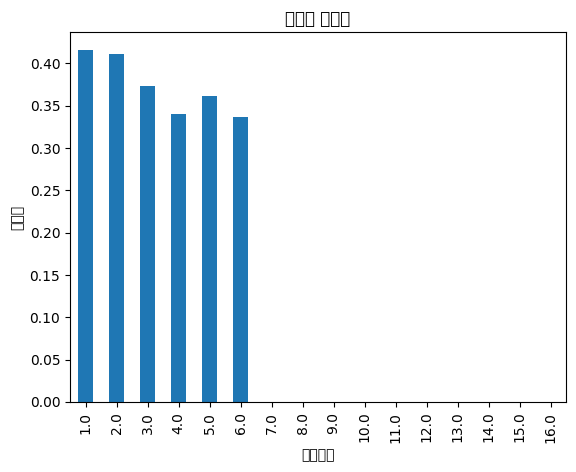

In [8]:
import matplotlib.pyplot as plt

plt.figure()
grade_win.plot(kind="bar")
plt.title("등급별 입상률")
plt.xlabel("마필등급")
plt.ylabel("입상률")
plt.show()

In [9]:
df["마필등급"].value_counts().sort_index()

마필등급
1.0      447
2.0      734
3.0     1907
4.0     4235
5.0     3539
6.0     4598
7.0       39
8.0       30
9.0       34
10.0      31
11.0      24
12.0      21
13.0      13
14.0       5
15.0       7
16.0       2
Name: count, dtype: int64

In [11]:
df_unique = df.drop_duplicates(subset="마명")

df_unique["마필등급"].value_counts().sort_index()

마필등급
1.0        5
2.0        6
3.0        4
4.0      251
5.0       24
6.0     1048
9.0        1
10.0       1
11.0       1
Name: count, dtype: int64

In [12]:
df.groupby("마명")["마필등급"].nunique().loc[lambda x: x > 1]

마명
가야스타      2
간다고       3
감사의힘      3
강나루       5
강남불청객     7
         ..
히어로전사     3
히어로초이스    3
히어로파이터    4
히어아이엠     3
힐링헤이븐     3
Name: 마필등급, Length: 860, dtype: int64

In [ ]:
df["순위점수(정규화_1등: 1 꼴등: 0)"] = 1 - (df["순위"] - 1) / (df["출주두수"] - 1)